In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/company_dataset.csv')


In [4]:
df.describe()

,Unnamed: 0,ratings
count,9056.000000,9056.000000
mean,4528.509607,3.897394
std,2614.415447,0.377954
min,0.000000,1.200000
25%,2264.750000,3.700000
50%,4528.500000,3.900000
75%,6792.250000,4.100000
max,9058.000000,5.000000


In [5]:
df.head()

,Unnamed: 0,name,ratings,review_count,ctype,years,hq,employees
0,0,TCS,3.8,(59.9k Reviews),Public,55 years old,"Mumbai,Maharashtra + 276 more",1 Lakh+ Employees (India)
1,1,Accenture,4.1,(38.3k Reviews),Public,34 years old,Dublin + 139 more,1 Lakh+ Employees (India)
2,2,Cognizant,3.9,(34.9k Reviews),Private,29 years old,Teaneck. New Jersey. + 109 more,1 Lakh+ Employees (India)
3,3,ICICI Bank,4.0,(28.5k Reviews),Public,29 years old,"Mumbai,Maharashtra + 1159 more",1 Lakh+ Employees (India)
4,4,Wipro,3.9,(28.4k Reviews),Public,78 years old,"Bangalore/Bengaluru,Karnataka + 235 more",1 Lakh+ Employees (India)


In [7]:
print(df.shape)
print(df.columns)
print(df.info())

(9056, 8)
Index(['Unnamed: 0', 'name', 'ratings', 'review_count', 'ctype', 'years', 'hq',
       'employees'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9056 entries, 0 to 9055
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    9056 non-null   int64  
 1   name          9056 non-null   object 
 2   ratings       9056 non-null   float64
 3   review_count  9056 non-null   object 
 4   ctype         9046 non-null   object 
 5   years         8542 non-null   object 
 6   hq            8887 non-null   object 
 7   employees     7466 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 566.1+ KB
None


In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/company_dataset.csv')

# Randomly sample 30 rows
df_sample = df.sample(n=30, random_state=42)

# Reset index (optional, cleaner output)
df_sample = df_sample.reset_index(drop=True)

# Save to new CSV
df_sample.to_csv('/content/company_sample_30.csv', index=False)

print("New dataset with 30 rows saved successfully!")

New dataset with 30 rows saved successfully!


In [9]:
df=pd.read_csv('/content/company_sample_30.csv')

In [10]:
print(df.shape)
print(df.columns)
print(df.info())

(30, 8)
Index(['Unnamed: 0', 'name', 'ratings', 'review_count', 'ctype', 'years', 'hq',
       'employees'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    30 non-null     int64  
 1   name          30 non-null     object 
 2   ratings       30 non-null     float64
 3   review_count  30 non-null     object 
 4   ctype         30 non-null     object 
 5   years         27 non-null     object 
 6   hq            29 non-null     object 
 7   employees     19 non-null     object 
dtypes: float64(1), int64(1), object(6)
memory usage: 2.0+ KB
None


In [11]:
df.head()

,Unnamed: 0,name,ratings,review_count,ctype,years,hq,employees
0,6280,Ministry of Home...,4.2,(98 Reviews),Private,76 years old,New Delhi + 12 more,51-200 Employees (India)
1,7268,Manav Rachna Int...,3.9,(84 Reviews),Faridabad + 2 more,501-1k Employees (India),26 years old,NaN
2,8613,Kalinga Universi...,3.4,(70 Reviews),Raipur + 7 more,201-500 Employees (India),10 years old,NaN
3,764,Tenneco,3.8,(754 Reviews),Private,83 years old,"Lake Forest,Illinois + 28 more",1k-5k Employees (India)
4,1721,Vedang Cellular ...,4.2,(349 Reviews),Mumbai + 48 more,501-1k Employees (India),13 years old,NaN


In [13]:
df['review_count'] = df['review_count'].str.replace(r'[^0-9]', '', regex=True)
df['review_count'] = pd.to_numeric(df['review_count'], errors='coerce')

In [14]:
df['years'] = df['years'].str.extract(r'(\d+)')
df['years'] = pd.to_numeric(df['years'], errors='coerce')

In [18]:
print(df)

                   name  ratings  review_count               ctype  years  \
0   Ministry of Home...      4.2            98             Private   76.0   
1   Manav Rachna Int...      3.9            84  Faridabad + 2 more  501.0   
2   Kalinga Universi...      3.4            70     Raipur + 7 more  201.0   
3               Tenneco      3.8           754             Private   83.0   
4   Vedang Cellular ...      4.2           349    Mumbai + 48 more  501.0   
5              Ican BPO      4.5           144             Private   14.0   
6   VOLTECH O AND M ...      4.0            78   Chennai + 15 more   11.0   
7              DP World      4.0           397              Public   18.0   
8       Damco Solutions      3.3           179             Private   27.0   
9   Global Opportuni...      3.9           110             Private   22.0   
10  High Court Luckn...      4.4           101   Lucknow + 17 more    NaN   
11             Toyo INK      4.2           117             Private   17.0   

In [19]:
df = df.drop(index=29)

In [20]:
print(df.isnull().sum())

name             0
ratings          0
review_count     0
ctype            0
years            3
hq               1
employees       10
dtype: int64


In [21]:
def fix_row(row):
    # Fix misplaced years
    if isinstance(row['hq'], str) and 'years old' in row['hq']:
        row['years'] = row['hq'].split()[0]
        row['hq'] = None

    # Fix misplaced employees
    if isinstance(row['hq'], str) and 'Employees' in row['hq']:
        row['employees'] = row['hq']
        row['hq'] = None

    return row

df = df.apply(fix_row, axis=1)

In [22]:
df['years'] = df['years'].astype(str).str.extract(r'(\d+)')
df['years'] = pd.to_numeric(df['years'], errors='coerce')

In [24]:
def clean_employees(val):
    if pd.isna(val):
        return None

    val = str(val).lower().replace(',', '').strip()

    # Handle "lakh"
    if 'lakh' in val:
        return 100000

    # Handle ranges like "1k-5k"
    if '-' in val:
        parts = val.split(' ')[0].split('-')

        def convert(x):
            if 'k' in x:
                return float(x.replace('k','')) * 1000
            else:
                return float(x)

        try:
            return (convert(parts[0]) + convert(parts[1])) / 2
        except:
            return None

    # Handle single values like "50k"
    if 'k' in val:
        try:
            return float(val.replace('k','')) * 1000
        except:
            return None

    return None

In [25]:
df['employees_clean'] = df['employees'].apply(clean_employees)

In [26]:
df

,name,ratings,review_count,ctype,years,hq,employees,employees_clean
0,Ministry of Home...,4.2,98,Private,76.0,New Delhi + 12 more,51-200 Employees (India),125.5
1,Manav Rachna Int...,3.9,84,Faridabad + 2 more,26.0,None,NaN,NaN
2,Kalinga Universi...,3.4,70,Raipur + 7 more,10.0,None,NaN,NaN
3,Tenneco,3.8,754,Private,83.0,"Lake Forest,Illinois + 28 more",1k-5k Employees (India),3000.0
4,Vedang Cellular ...,4.2,349,Mumbai + 48 more,13.0,None,NaN,NaN
5,Ican BPO,4.5,144,Private,14.0,Thane + 2 more,201-500 Employees (India),350.5
6,VOLTECH O AND M ...,4.0,78,Chennai + 15 more,14.0,None,NaN,NaN
7,DP World,4.0,397,Public,18.0,"Dubai,Jebel Ali + 40 more",1k-5k Employees (India),3000.0
8,Damco Solutions,3.3,179,Private,27.0,"Princeton,New Jersey + 15 more",501-1k Employees (India),750.5
9,Global Opportuni...,3.9,110,Private,22.0,"Delhi/NCR,Delhi + 12 more",51-200 Employees (India),125.5


In [27]:
df[['employees', 'employees_clean']].head(10)

,employees,employees_clean
0,51-200 Employees (India),125.5
1,NaN,NaN
2,NaN,NaN
3,1k-5k Employees (India),3000.0
4,NaN,NaN
5,201-500 Employees (India),350.5
6,NaN,NaN
7,1k-5k Employees (India),3000.0
8,501-1k Employees (India),750.5
9,51-200 Employees (India),125.5


In [28]:
df['years'].fillna(df['years'].mean(), inplace=True)
df['employees_clean'].fillna(df['employees_clean'].mean(), inplace=True)
df['ratings'].fillna(df['ratings'].mean(), inplace=True)

/tmp/ipykernel_12555/908796732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['years'].fillna(df['years'].mean(), inplace=True)
/tmp/ipykernel_12555/908796732.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [29]:
print("Average Rating:", df['ratings'].mean())
print("Total Reviews:", df['review_count'].sum())
print("Average Years:", df['years'].mean())
print("Average Employees:", df['employees_clean'].mean())

Average Rating: 3.9551724137931035
Total Reviews: 5967
Average Years: 31.692307692307693
Average Employees: 1971.9761904761906


In [32]:
df['hq'].fillna('Unknown', inplace=True)

/tmp/ipykernel_12555/1325883805.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['hq'].fillna('Unknown', inplace=True)


In [33]:
print(df.isnull().sum())

name               0
ratings            0
review_count       0
ctype              0
years              0
hq                 0
employees          8
employees_clean    0
dtype: int64


In [34]:
df

,name,ratings,review_count,ctype,years,hq,employees,employees_clean
0,Ministry of Home...,4.2,98,Private,76.000000,New Delhi + 12 more,51-200 Employees (India),125.50000
1,Manav Rachna Int...,3.9,84,Faridabad + 2 more,26.000000,Unknown,NaN,1971.97619
2,Kalinga Universi...,3.4,70,Raipur + 7 more,10.000000,Unknown,NaN,1971.97619
3,Tenneco,3.8,754,Private,83.000000,"Lake Forest,Illinois + 28 more",1k-5k Employees (India),3000.00000
4,Vedang Cellular ...,4.2,349,Mumbai + 48 more,13.000000,Unknown,NaN,1971.97619
5,Ican BPO,4.5,144,Private,14.000000,Thane + 2 more,201-500 Employees (India),350.50000
6,VOLTECH O AND M ...,4.0,78,Chennai + 15 more,14.000000,Unknown,NaN,1971.97619
7,DP World,4.0,397,Public,18.000000,"Dubai,Jebel Ali + 40 more",1k-5k Employees (India),3000.00000
8,Damco Solutions,3.3,179,Private,27.000000,"Princeton,New Jersey + 15 more",501-1k Employees (India),750.50000
9,Global Opportuni...,3.9,110,Private,22.000000,"Delhi/NCR,Delhi + 12 more",51-200 Employees (India),125.50000


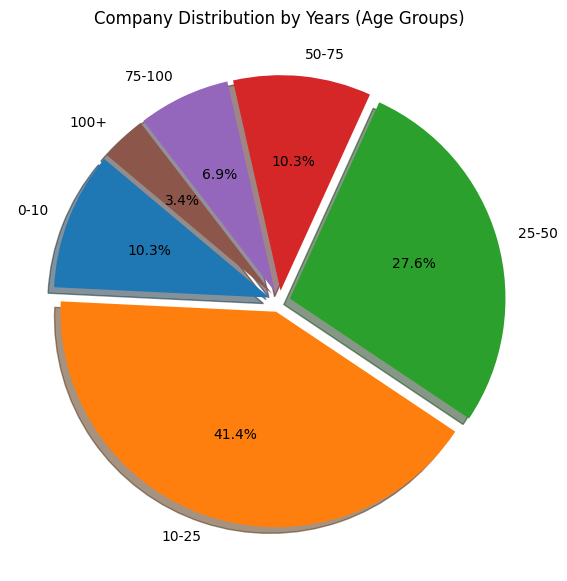

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (if not already loaded)
# df = pd.read_csv('/content/cleaned_company_dataset.csv')

# Step 1: Create age groups
bins = [0, 10, 25, 50, 75, 100, 200]
labels = ['0-10', '10-25', '25-50', '50-75', '75-100', '100+']

df['year_group'] = pd.cut(df['years'], bins=bins, labels=labels)

# Step 2: Count companies in each group
year_counts = df['year_group'].value_counts().sort_index()

# Step 3: Plot pie chart
plt.figure(figsize=(7,7))

plt.pie(
    year_counts,
    labels=year_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.05]*len(year_counts),  # optional highlight effect
    shadow=True
)

plt.title("Company Distribution by Years (Age Groups)")
plt.show()

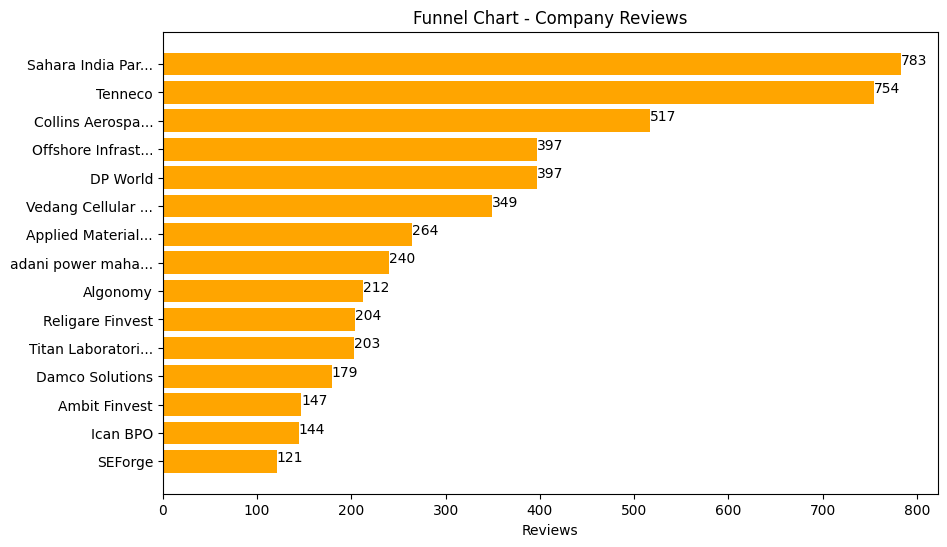

In [38]:
plt.figure(figsize=(10,6))

plt.barh(
    top_df['name'],
    top_df['review_count'],
    color='orange'
)

plt.xlabel("Reviews")
plt.title("Funnel Chart - Company Reviews")

plt.gca().invert_yaxis()

# Add values on bars
for i, v in enumerate(top_df['review_count']):
    plt.text(v, i, str(v))

plt.show()

In [39]:
h=df[['name','hq']].head(10)
display(h)

,name,hq
0,Ministry of Home...,New Delhi + 12 more
1,Manav Rachna Int...,Unknown
2,Kalinga Universi...,Unknown
3,Tenneco,"Lake Forest,Illinois + 28 more"
4,Vedang Cellular ...,Unknown
5,Ican BPO,Thane + 2 more
6,VOLTECH O AND M ...,Unknown
7,DP World,"Dubai,Jebel Ali + 40 more"
8,Damco Solutions,"Princeton,New Jersey + 15 more"
9,Global Opportuni...,"Delhi/NCR,Delhi + 12 more"


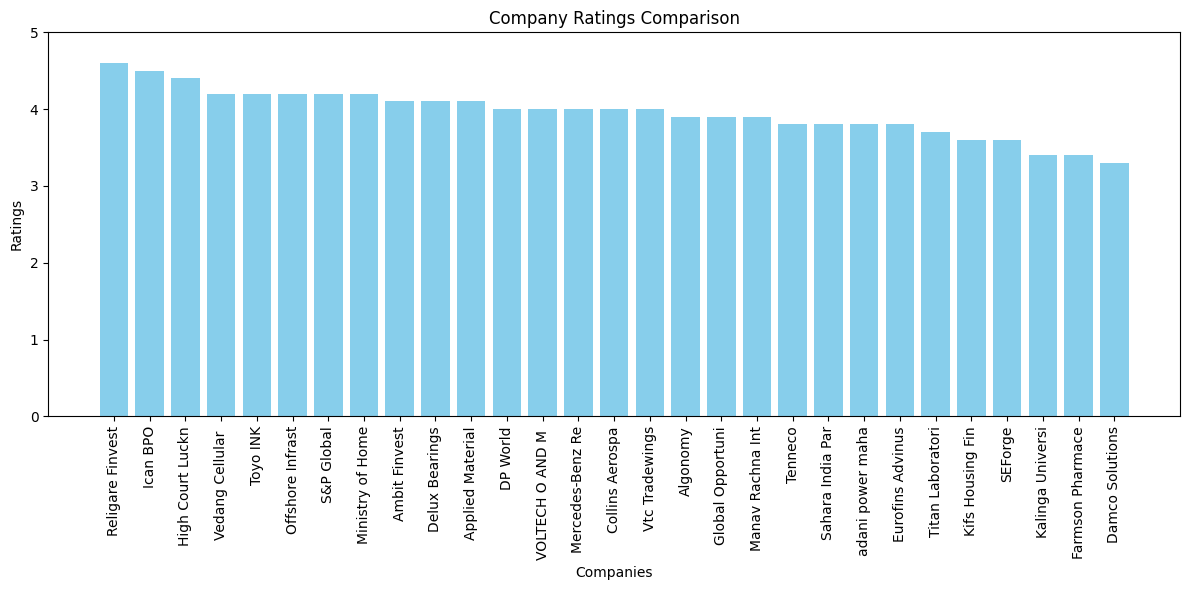

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is in a DataFrame called df
# If not, first create it:
# df = pd.read_csv("your_file.csv")

# Clean company names for better plotting (optional but recommended)
df["name_short"] = df["name"].str.replace("...", "", regex=False)

# Sort by ratings for better visualization
df_sorted = df.sort_values(by="ratings", ascending=False)

plt.figure(figsize=(12,6))

plt.bar(df_sorted["name_short"], df_sorted["ratings"], color="skyblue")

plt.xticks(rotation=90)
plt.xlabel("Companies")
plt.ylabel("Ratings")
plt.title("Company Ratings Comparison")
plt.ylim(0, 5)  # since ratings are typically out of 5

plt.tight_layout()
plt.show()

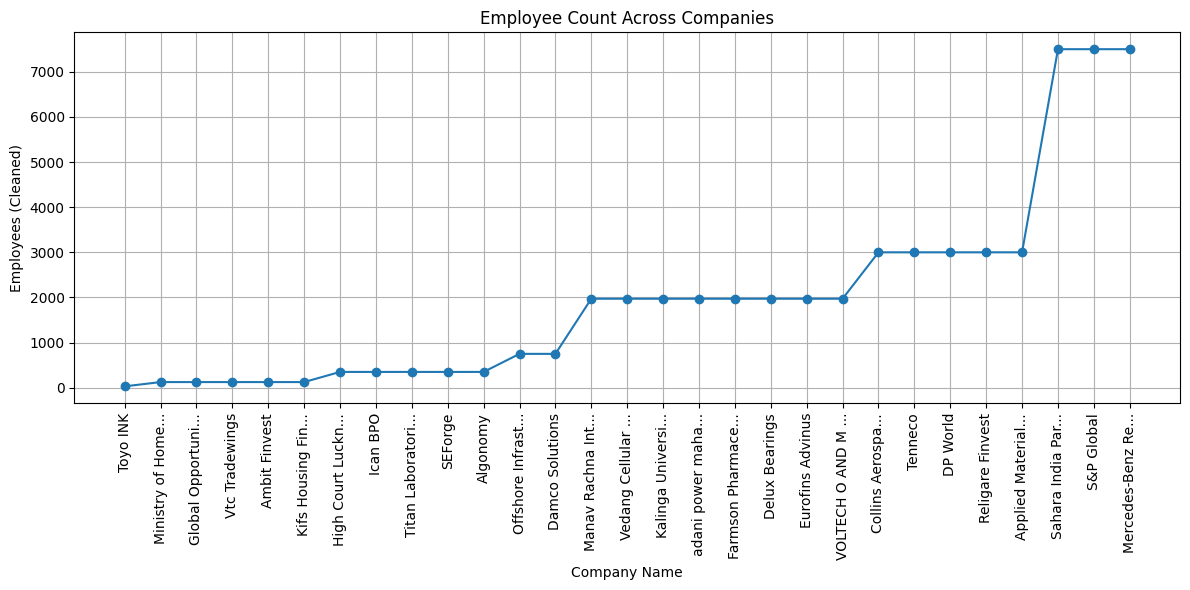

In [41]:
import matplotlib.pyplot as plt

# Sort by employee count for better visual flow
df_sorted = df.sort_values(by='employees_clean')

plt.figure(figsize=(12,6))

plt.plot(df_sorted['name'], df_sorted['employees_clean'], marker='o')

plt.xticks(rotation=90)
plt.xlabel('Company Name')
plt.ylabel('Employees (Cleaned)')
plt.title('Employee Count Across Companies')
plt.grid(True)

plt.tight_layout()
plt.show()